<a href="https://colab.research.google.com/github/fralfaro/ics294-latex/blob/main/colab/regresion_wage_inferencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión lineal con el dataset `wage`

En este notebook estudiaremos regresión lineal univariada, regresión lineal multivariada e inferencia sobre parámetros usando el dataset `wage` del paquete `wooldridge`.

El ejemplo central será:

$$
\log(wage_i)=\beta_0+\beta_1 educ_i+\beta_2 exper_i+\beta_3 tenure_i+u_i
$$

Para ejecutar este notebook en Google Colab, use **Runtime > Change runtime type** y seleccione **R** como lenguaje.

## 1. Preparación

Partiremos cargando paquetes. Usaremos `dplyr` para análisis estadístico, `ggplot2` para gráficos, `wooldridge` para los datos.

In [17]:
library(dplyr)
library(ggplot2)
library(wooldridge)

theme_set(theme_minimal(base_size = 12))

## 2. Carga y primera mirada a los datos

El comando `data("wage")` carga una base de datos clásica de Wooldridge. Cada fila representa a una persona y contiene variables laborales como salario, educación, experiencia y antigüedad.

In [18]:
data("wage1")
wage_df <- as_tibble(wage1)

glimpse(wage_df)

Rows: 526
Columns: 24
$ wage     <dbl> 3.10, 3.24, 3.00, 6.00, 5.30, 8.75, 11.25, 5.00, 3.60, 18.18,…
$ educ     <int> 11, 12, 11, 8, 12, 16, 18, 12, 12, 17, 16, 13, 12, 12, 12, 16…
$ exper    <int> 2, 22, 2, 44, 7, 9, 15, 5, 26, 22, 8, 3, 15, 18, 31, 14, 10, …
$ tenure   <int> 0, 2, 0, 28, 2, 8, 7, 3, 4, 21, 2, 0, 0, 3, 15, 0, 0, 10, 0, …
$ nonwhite <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ female   <int> 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1…
$ married  <int> 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0…
$ numdep   <int> 2, 3, 2, 0, 1, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 3, 0, 0…
$ smsa     <int> 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ northcen <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ south    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ west     <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ construc <int> 0

In [19]:
head(wage_df, 10)

wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,⋯,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>
3.10,11,2,0,0,1,0,2,1,0,⋯,0,0,0,0,0,0,0,1.131402,4,0
3.24,12,22,2,0,1,1,3,1,0,⋯,0,0,1,0,0,0,1,1.175573,484,4
3.00,11,2,0,0,0,0,2,0,0,⋯,0,1,0,0,0,0,0,1.098612,4,0
6.00,8,44,28,0,0,1,0,1,0,⋯,0,0,0,0,0,1,0,1.791759,1936,784
5.30,12,7,2,0,0,1,1,0,0,⋯,0,0,0,0,0,0,0,1.667707,49,4
8.75,16,9,8,0,0,1,0,1,0,⋯,0,0,0,1,1,0,0,2.169054,81,64
11.25,18,15,7,0,0,0,0,1,0,⋯,0,1,0,0,1,0,0,2.420368,225,49
5.00,12,5,3,0,1,0,0,1,0,⋯,0,0,0,0,1,0,0,1.609438,25,9
3.60,12,26,4,0,1,0,2,1,0,⋯,0,1,0,0,1,0,0,1.280934,676,16


Algunas variables relevantes:

- `wage`: salario por hora.
- `lwage`: logaritmo natural del salario. También podemos calcularlo como `log(wage)`.
- `educ`: años de educación.
- `exper`: años de experiencia laboral potencial.
- `tenure`: años de antigüedad con el empleador actual.
- `female`, `married`, `nonwhite`: variables binarias que pueden servir para extensiones del modelo.

## 3. Análisis estadístico con `dplyr`

Antes de estimar modelos, conviene describir la base. Esto ayuda a detectar rangos extraños, valores faltantes, dispersión y posibles transformaciones necesarias.

In [20]:
wage_df %>%
  summarise(
    n = n(),
    salario_promedio = mean(wage, na.rm = TRUE),
    salario_mediano = median(wage, na.rm = TRUE),
    salario_min = min(wage, na.rm = TRUE),
    salario_max = max(wage, na.rm = TRUE),
    educ_promedio = mean(educ, na.rm = TRUE),
    exper_promedio = mean(exper, na.rm = TRUE),
    tenure_promedio = mean(tenure, na.rm = TRUE)
  )

n,salario_promedio,salario_mediano,salario_min,salario_max,educ_promedio,exper_promedio,tenure_promedio
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
526,5.896103,4.65,0.53,24.98,12.56274,17.01711,5.104563


In [21]:
wage_df %>%
  summarise(across(
    c(wage, lwage, educ, exper, tenure),
    list(
      media = ~mean(.x, na.rm = TRUE),
      sd = ~sd(.x, na.rm = TRUE),
      p25 = ~quantile(.x, 0.25, na.rm = TRUE),
      mediana = ~median(.x, na.rm = TRUE),
      p75 = ~quantile(.x, 0.75, na.rm = TRUE)
    )
  ))

wage_media,wage_sd,wage_p25,wage_mediana,wage_p75,lwage_media,lwage_sd,lwage_p25,lwage_mediana,lwage_p75,⋯,exper_media,exper_sd,exper_p25,exper_mediana,exper_p75,tenure_media,tenure_sd,tenure_p25,tenure_mediana,tenure_p75
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5.896103,3.693086,3.33,4.65,6.88,1.623268,0.5315382,1.202972,1.536867,1.928619,⋯,17.01711,13.57216,5,13.5,26,5.104563,7.224462,0,2,7


In [22]:
wage_df %>%
  group_by(female) %>%
  summarise(
    n = n(),
    wage_promedio = mean(wage, na.rm = TRUE),
    lwage_promedio = mean(lwage, na.rm = TRUE),
    educ_promedio = mean(educ, na.rm = TRUE),
    .groups = "drop"
  )

female,n,wage_promedio,lwage_promedio,educ_promedio
<int>,<int>,<dbl>,<dbl>,<dbl>
0,274,7.099489,1.813570,12.78832
1,252,4.587659,1.416353,12.31746


In [23]:
wage_df %>%
  count(educ, sort = TRUE) %>%
  head(10)

educ,n
<int>,<int>
12,198
16,68
14,53
13,39
10,30
11,29
8,22
15,21
18,19


## 4. Análisis gráfico con `ggplot2`

Primero miramos la distribución del salario y del log-salario. En econometría salarial suele usarse `log(wage)` porque reduce asimetrías y permite interpretar coeficientes aproximadamente como cambios porcentuales.

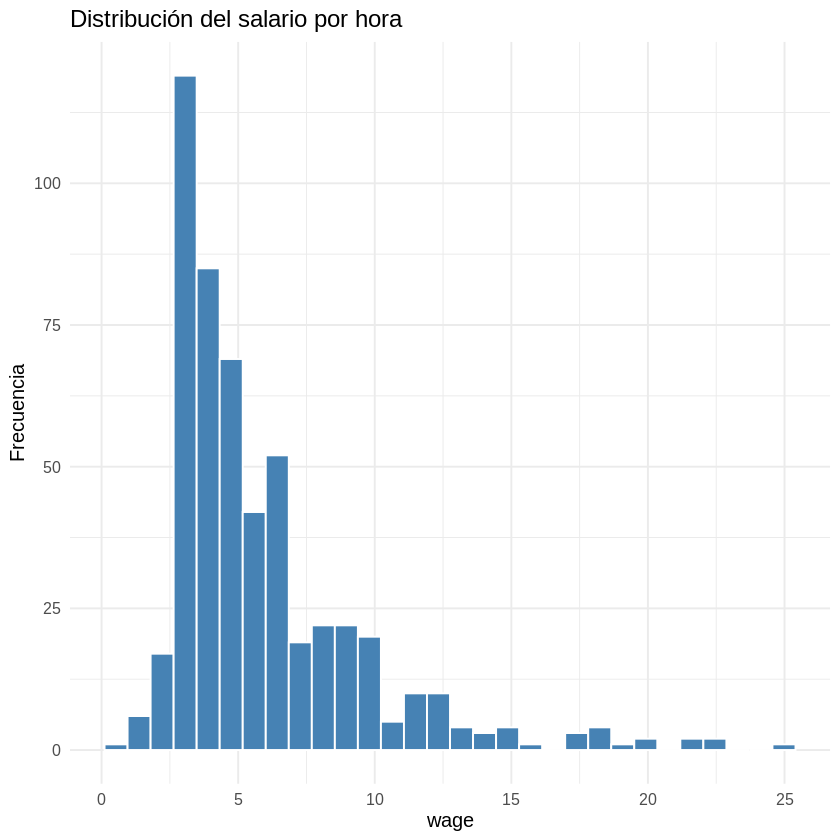

In [24]:
ggplot(wage_df, aes(x = wage)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  labs(
    title = "Distribución del salario por hora",
    x = "wage",
    y = "Frecuencia"
  )

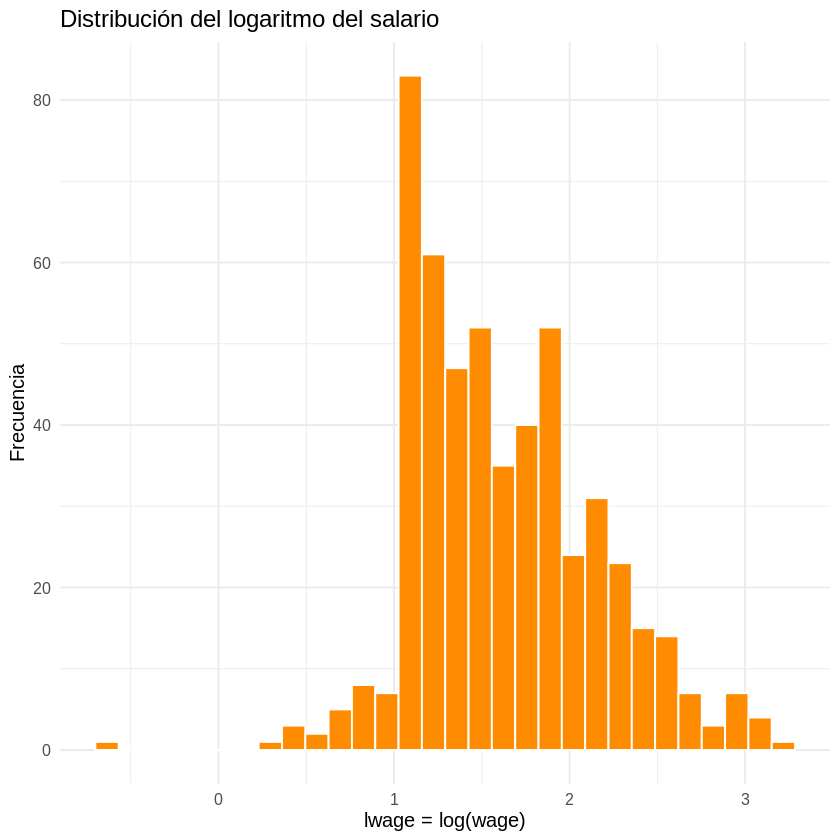

In [25]:
ggplot(wage_df, aes(x = lwage)) +
  geom_histogram(bins = 30, fill = "darkorange", color = "white") +
  labs(
    title = "Distribución del logaritmo del salario",
    x = "lwage = log(wage)",
    y = "Frecuencia"
  )

`geom_smooth()` using formula = 'y ~ x'


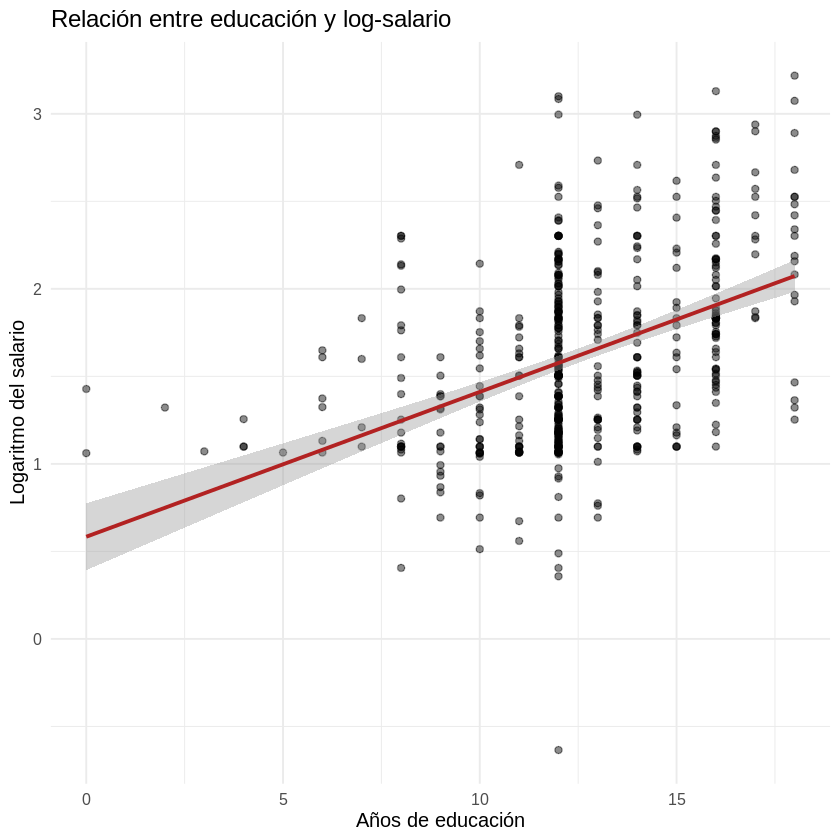

In [26]:
ggplot(wage_df, aes(x = educ, y = lwage)) +
  geom_point(alpha = 0.45) +
  geom_smooth(method = "lm", se = TRUE, color = "firebrick") +
  labs(
    title = "Relación entre educación y log-salario",
    x = "Años de educación",
    y = "Logaritmo del salario"
  )

In [27]:
wage_df %>%
  select(lwage, educ, exper, tenure) %>%
  cor(use = "complete.obs")

,lwage,educ,exper,tenure
lwage,1.0000000,0.43105276,0.1113729,0.32553794
educ,0.4310528,1.00000000,-0.2995418,-0.05617257
exper,0.1113729,-0.29954184,1.0000000,0.49929145
tenure,0.3255379,-0.05617257,0.4992914,1.00000000


## 5. Regresión lineal univariada

Comenzamos con un modelo simple:

$$
\log(wage_i)=\beta_0+\beta_1 educ_i+u_i
$$

Aquí `educ` es la única variable explicativa. El parámetro $\beta_1$ mide la diferencia esperada en `log(wage)` asociada a un año adicional de educación.

In [28]:
modelo_uni <- lm(lwage ~ educ, data = wage_df)
summary(modelo_uni)


Call:
lm(formula = lwage ~ educ, data = wage_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.21158 -0.36393 -0.07263  0.29712  1.52339 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.583773   0.097336   5.998 3.74e-09 ***
educ        0.082744   0.007567  10.935  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4801 on 524 degrees of freedom
Multiple R-squared:  0.1858,	Adjusted R-squared:  0.1843 
F-statistic: 119.6 on 1 and 524 DF,  p-value: < 2.2e-16


### Interpretación del coeficiente de educación

Como la variable dependiente está en logaritmos y `educ` está en niveles, el coeficiente de `educ` se interpreta aproximadamente como un cambio porcentual en el salario ante un año adicional de educación:

$$
100\cdot \beta_1 \%.
$$

La interpretación exacta es:

$$
100\cdot (e^{\beta_1}-1) \%.
$$

In [29]:
beta_educ_uni <- coef(modelo_uni)["educ"]

interpretacion_uni <- tibble(
  beta_educ = beta_educ_uni,
  efecto_aprox_porcentual = 100 * beta_educ_uni,
  efecto_exacto_porcentual = 100 * (exp(beta_educ_uni) - 1)
)

interpretacion_uni

beta_educ,efecto_aprox_porcentual,efecto_exacto_porcentual
<dbl>,<dbl>,<dbl>
0.08274437,8.274437,8.626409


## 6. Inferencia sobre parámetros en el modelo univariado

La inferencia pregunta si el efecto estimado es estadísticamente distinguible de un valor de referencia. El caso más común es:

$$
H_0: \beta_1 = 0
$$

contra

$$
H_1: \beta_1 \neq 0
eq 0.
$$

El resumen de `lm` entrega el estadístico t y el p-value. También podemos calcular intervalos de confianza.

In [30]:
summary(modelo_uni)$coefficients
confint(modelo_uni, level = 0.95)

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),0.58377267,0.097335835,5.99751,3.736706e-09
educ,0.08274437,0.007566694,10.93534,3.270644e-25


,2.5 %,97.5 %
(Intercept),0.39255627,0.77498906
educ,0.06787958,0.09760915


In [31]:
tabla_uni <- as.data.frame(summary(modelo_uni)$coefficients)
tabla_uni$parametro <- rownames(tabla_uni)
rownames(tabla_uni) <- NULL

tabla_uni %>%
  select(parametro, Estimate, `Std. Error`, `t value`, `Pr(>|t|)`)

parametro,Estimate,Std. Error,t value,Pr(>|t|)
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.58377267,0.097335835,5.99751,3.736706e-09
educ,0.08274437,0.007566694,10.93534,3.270644e-25


Si el intervalo de confianza de `educ` no contiene cero, rechazamos $H_0: \beta_1=0$ al 5%. Si el p-value es pequeño, también rechazamos la hipótesis nula.

## 7. Regresión lineal multivariada

Ahora agregamos experiencia y antigüedad laboral:

$$
\log(wage_i)=\beta_0+\beta_1 educ_i+\beta_2 exper_i+\beta_3 tenure_i+u_i
$$

Este modelo permite estudiar el efecto parcial de educación manteniendo constantes experiencia y antigüedad.

In [32]:
modelo_multi <- lm(lwage ~ educ + exper + tenure, data = wage_df)
summary(modelo_multi)


Call:
lm(formula = lwage ~ educ + exper + tenure, data = wage_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.05802 -0.29645 -0.03265  0.28788  1.42809 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.284360   0.104190   2.729  0.00656 ** 
educ        0.092029   0.007330  12.555  < 2e-16 ***
exper       0.004121   0.001723   2.391  0.01714 *  
tenure      0.022067   0.003094   7.133 3.29e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4409 on 522 degrees of freedom
Multiple R-squared:  0.316,	Adjusted R-squared:  0.3121 
F-statistic: 80.39 on 3 and 522 DF,  p-value: < 2.2e-16


In [33]:
summary(modelo_multi)
confint(modelo_multi, level = 0.95)


Call:
lm(formula = lwage ~ educ + exper + tenure, data = wage_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.05802 -0.29645 -0.03265  0.28788  1.42809 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.284360   0.104190   2.729  0.00656 ** 
educ        0.092029   0.007330  12.555  < 2e-16 ***
exper       0.004121   0.001723   2.391  0.01714 *  
tenure      0.022067   0.003094   7.133 3.29e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4409 on 522 degrees of freedom
Multiple R-squared:  0.316,	Adjusted R-squared:  0.3121 
F-statistic: 80.39 on 3 and 522 DF,  p-value: < 2.2e-16


,2.5 %,97.5 %
(Intercept),0.0796755675,0.48904351
educ,0.0776292151,0.10642876
exper,0.0007356984,0.00750652
tenure,0.0159896854,0.02814475


### Interpretación económica del modelo multivariado

- $\beta_1$: cambio esperado en `log(wage)` ante un año adicional de educación, manteniendo constantes `exper` y `tenure`.
- $\beta_2$: cambio esperado en `log(wage)` ante un año adicional de experiencia, manteniendo constantes `educ` y `tenure`.
- $\beta_3$: cambio esperado en `log(wage)` ante un año adicional de antigüedad en la empresa, manteniendo constantes `educ` y `exper`.

Como la variable dependiente está en logaritmos, cada coeficiente puede leerse aproximadamente como porcentaje multiplicando por 100.

In [34]:
coef_multi <- coef(modelo_multi)

tibble(
  variable = names(coef_multi),
  beta = as.numeric(coef_multi)
) %>%
  filter(variable != "(Intercept)") %>%
  mutate(
    efecto_aprox_porcentual = 100 * beta,
    efecto_exacto_porcentual = 100 * (exp(beta) - 1)
  )

variable,beta,efecto_aprox_porcentual,efecto_exacto_porcentual
<chr>,<dbl>,<dbl>,<dbl>
educ,0.092028988,9.2028988,9.6396604
exper,0.004121109,0.4121109,0.4129613
tenure,0.022067218,2.2067218,2.2312500


## 8. Comparación entre modelo univariado y multivariado

Es común que el coeficiente de `educ` cambie al agregar controles. Esto ocurre porque el modelo simple puede estar mezclando el efecto de educación con otras variables relacionadas con educación y salarios.

In [35]:
coef_uni <- summary(modelo_uni)$coefficients["educ", ]
coef_multi_educ <- summary(modelo_multi)$coefficients["educ", ]

tibble(
  modelo = c("Univariado: lwage ~ educ", "Multivariado: lwage ~ educ + exper + tenure"),
  beta_educ = c(coef_uni["Estimate"], coef_multi_educ["Estimate"]),
  error_estandar = c(coef_uni["Std. Error"], coef_multi_educ["Std. Error"]),
  estadistico_t = c(coef_uni["t value"], coef_multi_educ["t value"]),
  p_value = c(coef_uni["Pr(>|t|)"], coef_multi_educ["Pr(>|t|)"])
)

modelo,beta_educ,error_estandar,estadistico_t,p_value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Univariado: lwage ~ educ,0.08274437,0.007566694,10.93534,3.270644e-25
Multivariado: lwage ~ educ + exper + tenure,0.09202899,0.007329923,12.55525,8.824197e-32


In [36]:
resumen_modelos <- tibble(
  modelo = c("Univariado", "Multivariado"),
  r2 = c(summary(modelo_uni)$r.squared, summary(modelo_multi)$r.squared),
  r2_ajustado = c(summary(modelo_uni)$adj.r.squared, summary(modelo_multi)$adj.r.squared),
  error_residual = c(summary(modelo_uni)$sigma, summary(modelo_multi)$sigma),
  n = c(nobs(modelo_uni), nobs(modelo_multi))
)

resumen_modelos

modelo,r2,r2_ajustado,error_residual,n
<chr>,<dbl>,<dbl>,<dbl>,<int>
Univariado,0.1858065,0.1842527,0.4800786,526
Multivariado,0.3160133,0.3120824,0.4408620,526


## 9. Pruebas de hipótesis individuales

Para una prueba individual, por ejemplo sobre experiencia:

$$
H_0: \beta_2=0
$$

miramos el estadístico t y el p-value asociado a `exper` en el modelo multivariado.

In [37]:
summary(modelo_multi)$coefficients["exper", ]

Estimate  Std. Error     t value    Pr(>|t|) 
0.004121109 0.001723277 2.391437107 0.017135623

La prueba individual para `exper` ya aparece en `summary(modelo_multi)`: el estadístico t evalúa $H_0: \beta_2=0$ usando el error estándar del coeficiente estimado. Así mantenemos el notebook usando solo las tres librerías principales.

In [38]:
# Cálculo manual del estadístico t para H0: beta_exper = 0
beta_exper <- coef(modelo_multi)["exper"]
se_exper <- summary(modelo_multi)$coefficients["exper", "Std. Error"]
t_exper <- beta_exper / se_exper
gl <- df.residual(modelo_multi)
p_value_exper <- 2 * pt(abs(t_exper), df = gl, lower.tail = FALSE)

tibble(
  hipotesis = "H0: beta_exper = 0",
  beta = beta_exper,
  error_estandar = se_exper,
  t = t_exper,
  grados_libertad = gl,
  p_value = p_value_exper
)

hipotesis,beta,error_estandar,t,grados_libertad,p_value
<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
H0: beta_exper = 0,0.004121109,0.001723277,2.391437,522,0.01713562


## 10. Pruebas conjuntas de parámetros

A veces queremos preguntar si un grupo de variables aporta conjuntamente al modelo. Por ejemplo:

$$
H_0: \beta_2=0 \quad \text{y} \quad \beta_3=0
$$

Esto pregunta si experiencia y antigüedad son conjuntamente irrelevantes una vez controlamos por educación.

In [39]:
modelo_restringido <- lm(lwage ~ educ, data = wage_df)
anova(modelo_restringido, modelo_multi)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,524,120.7691,NA,NA,NA,NA
2,522,101.4556,2,19.31355,49.68516,1.768154e-20


La comparación con `anova(modelo_restringido, modelo_multi)` entrega una prueba F. Aquí el modelo restringido impone que los coeficientes de `exper` y `tenure` son cero. Si el p-value es pequeño, rechazamos que ambas variables sean conjuntamente irrelevantes.

## 11. Intervalos de confianza e incertidumbre

El estimador puntual no cuenta toda la historia. Los intervalos de confianza muestran un rango de valores plausibles para cada parámetro.

In [40]:
ic_multi <- confint(modelo_multi, level = 0.95)
coef_multi <- coef(modelo_multi)

tibble(
  variable = names(coef_multi),
  beta = as.numeric(coef_multi),
  limite_inferior = ic_multi[, 1],
  limite_superior = ic_multi[, 2]
)

variable,beta,limite_inferior,limite_superior
<chr>,<dbl>,<dbl>,<dbl>
(Intercept),0.284359541,0.0796755675,0.48904351
educ,0.092028988,0.0776292151,0.10642876
exper,0.004121109,0.0007356984,0.00750652
tenure,0.022067218,0.0159896854,0.02814475


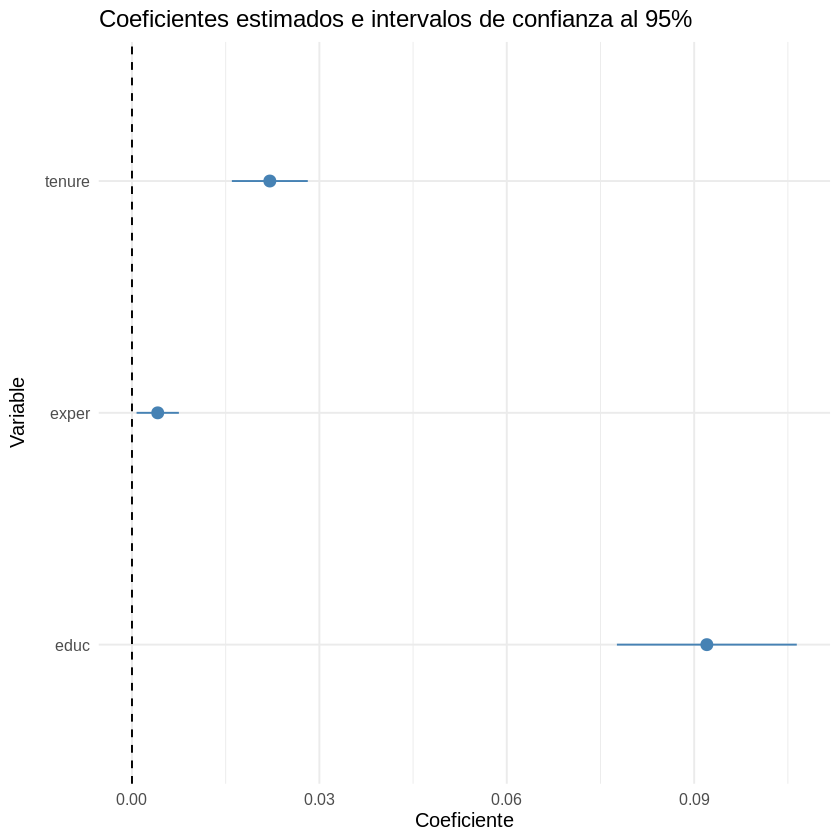

In [41]:
ic_multi <- confint(modelo_multi, level = 0.95)
coef_multi <- coef(modelo_multi)

tibble(
  variable = names(coef_multi),
  beta = as.numeric(coef_multi),
  limite_inferior = ic_multi[, 1],
  limite_superior = ic_multi[, 2]
) %>%
  filter(variable != "(Intercept)") %>%
  ggplot(aes(x = variable, y = beta, ymin = limite_inferior, ymax = limite_superior)) +
  geom_pointrange(color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed") +
  coord_flip() +
  labs(
    title = "Coeficientes estimados e intervalos de confianza al 95%",
    x = "Variable",
    y = "Coeficiente"
  )

## 12. Diagnóstico visual básico

Los residuos ayudan a revisar si el ajuste parece razonable. No prueban causalidad, pero sí muestran patrones problemáticos como no linealidad fuerte o varianza no constante.

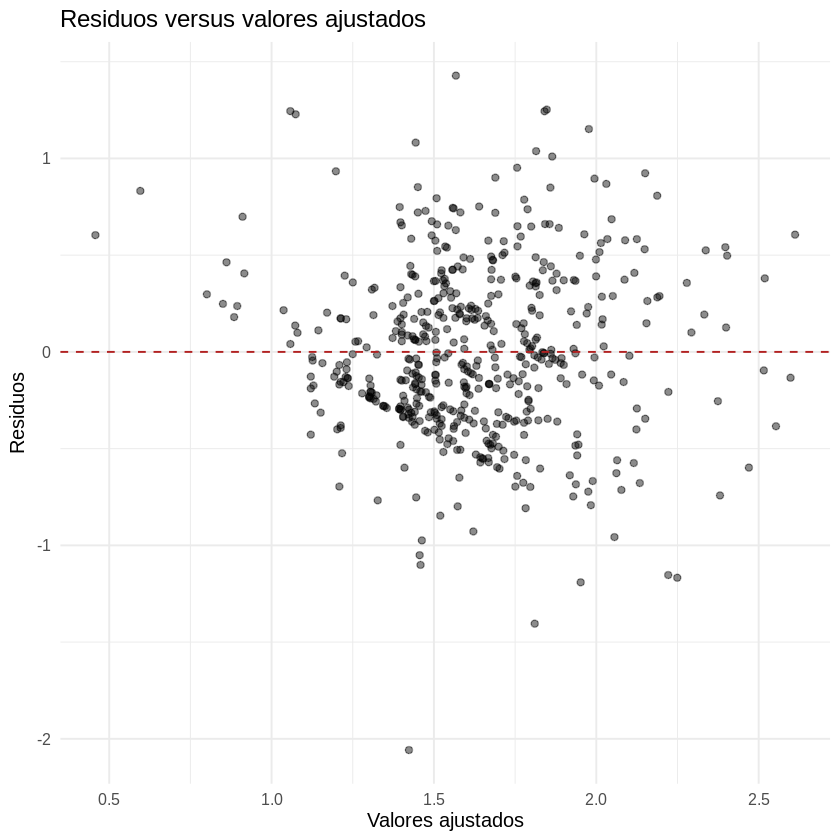

In [42]:
wage_aug <- tibble(
  ajustado = fitted(modelo_multi),
  residuo = resid(modelo_multi),
  residuo_estandarizado = rstandard(modelo_multi)
)

ggplot(wage_aug, aes(x = ajustado, y = residuo)) +
  geom_point(alpha = 0.45) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "firebrick") +
  labs(
    title = "Residuos versus valores ajustados",
    x = "Valores ajustados",
    y = "Residuos"
  )

Si los residuos muestran una nube sin patrón claro alrededor de cero, el ajuste lineal parece razonable como primera aproximación. Si aparece una forma curva o una dispersión que aumenta mucho, conviene considerar transformaciones, términos no lineales o errores estándar robustos en una etapa posterior.

## 12. Diagnóstico visual básico

Los residuos ayudan a revisar si el ajuste parece razonable. No prueban causalidad, pero sí muestran patrones problemáticos como no linealidad fuerte o varianza no constante.

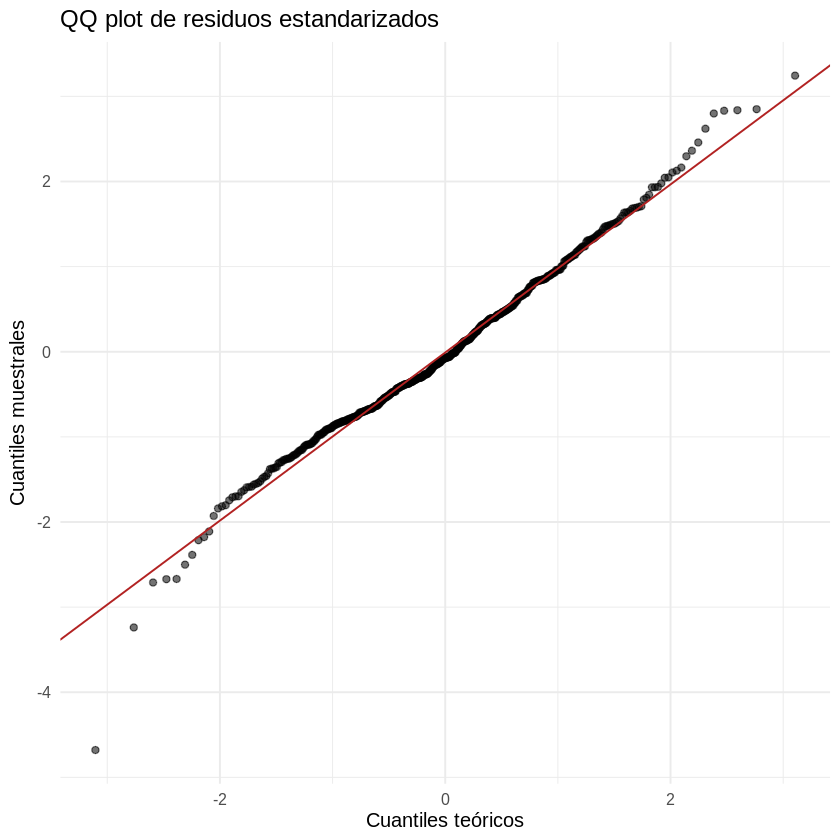

In [43]:
ggplot(wage_aug, aes(sample = residuo_estandarizado)) +
  stat_qq(alpha = 0.55) +
  stat_qq_line(color = "firebrick") +
  labs(
    title = "QQ plot de residuos estandarizados",
    x = "Cuantiles teóricos",
    y = "Cuantiles muestrales"
  )

In [44]:
ggplot(wage_aug, aes(sample = .std.resid)) +
  stat_qq(alpha = 0.55) +
  stat_qq_line(color = "firebrick") +
  labs(
    title = "QQ plot de residuos estandarizados",
    x = "Cuantiles teóricos",
    y = "Cuantiles muestrales"
  )

ERROR while rich displaying an object: Error in `stat_qq()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object '.std.resid' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 

## 13. Predicción e interpretación práctica

Podemos construir perfiles hipotéticos y predecir su log-salario esperado. Luego transformamos con exponencial para volver a unidades de salario.

In [45]:
nuevos_trabajadores <- tibble(
  educ = c(12, 16, 18),
  exper = c(10, 10, 10),
  tenure = c(5, 5, 5)
)

predicciones <- predict(
  modelo_multi,
  newdata = nuevos_trabajadores,
  interval = "confidence",
  level = 0.95
)

bind_cols(nuevos_trabajadores, as_tibble(predicciones)) %>%
  mutate(
    wage_estimado = exp(fit),
    wage_low = exp(lwr),
    wage_high = exp(upr)
  )

educ,exper,tenure,fit,lwr,upr,wage_estimado,wage_low,wage_high
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12,10,5,1.540255,1.493770,1.586739,4.665778,4.453855,4.887785
16,10,5,1.908371,1.847589,1.969152,6.742094,6.344505,7.164599
18,10,5,2.092429,2.009065,2.175792,8.104573,7.456345,8.809156


## 14. Extensión: modelo con forma cuadrática

La experiencia puede tener rendimientos decrecientes. Para permitir una relación curva, agregamos `exper^2`:

$$
\log(wage_i)=\beta_0+\beta_1 educ_i+\beta_2 exper_i+\beta_3 exper_i^2+\beta_4 tenure_i+u_i
$$

In [46]:
modelo_cuad <- lm(lwage ~ educ + exper + I(exper^2) + tenure, data = wage_df)
summary(modelo_cuad)


Call:
lm(formula = lwage ~ educ + exper + I(exper^2) + tenure, data = wage_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.97087 -0.26809 -0.03463  0.27663  1.28678 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.1983445  0.1019556   1.945   0.0523 .  
educ         0.0853489  0.0071885  11.873  < 2e-16 ***
exper        0.0328542  0.0051135   6.425 2.98e-10 ***
I(exper^2)  -0.0006606  0.0001111  -5.945 5.08e-09 ***
tenure       0.0208413  0.0030037   6.938 1.18e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.427 on 521 degrees of freedom
Multiple R-squared:  0.3595,	Adjusted R-squared:  0.3545 
F-statistic: 73.09 on 4 and 521 DF,  p-value: < 2.2e-16


In [47]:
summary(modelo_cuad)$coefficients["I(exper^2)", ]

Estimate    Std. Error       t value      Pr(>|t|) 
-6.606217e-04  1.111285e-04 -5.944665e+00  5.077505e-09

Si el coeficiente de `exper^2` es negativo y estadísticamente significativo, sugiere que el retorno marginal de la experiencia disminuye a medida que aumenta la experiencia.

## 15. Resumen final

En este notebook hicimos lo siguiente:

1. Cargamos y describimos el dataset `wage`.
2. Usamos `dplyr` para análisis estadístico inicial.
3. Usamos `ggplot2` para estudiar distribuciones y relaciones bivariadas.
4. Estimamos un modelo univariado: `lwage ~ educ`.
5. Estimamos el modelo multivariado central: `lwage ~ educ + exper + tenure`.
6. Interpretamos coeficientes en modelos log-nivel.
7. Revisamos inferencia individual, intervalos de confianza y pruebas F usando funciones base de R.
8. Cerramos con diagnóstico visual, predicción y una extensión cuadrática.

Todo el análisis usa solo tres paquetes: `dplyr`, `ggplot2` y `wooldridge`.